In [24]:
import json
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import requests
from shapely.geometry import shape

import pandas as pd

# # Read the GeoJSON file
# geojson_path = '/Users/ryanmc/Documents/Complex_Risk_Science/dev/Complex-Risk-Collective/.github/Projects/NASA-disasters-grid-resilience/notebooks/us_states_north_36_plus_ca.geojson'
# gdf = gpd.read_file(geojson_path)

# print(f"Number of states: {len(gdf)}")
# print(f"\nStates included:")
# print(gdf[['name', 'abbreviation']].sort_values('name').to_string(index=False))

In [18]:
# Load the US County GeoJSON file
counties_url = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
print(f"Downloading county geometries from {counties_url}...")
response = requests.get(counties_url)
counties_geojson = response.json()


# # Convert to GeoDataFrame
# counties_records = []
# for feature in counties_geojson['features']:
#     geom = shape(feature['geometry'])
#     fips = feature['id']
#     counties_records.append({
#         'fips_code': fips,
#         'geometry': geom
#     })

# counties_gdf = gpd.GeoDataFrame(counties_records, crs='EPSG:4326')
# print(f"\nCounties GeoDataFrame shape: {counties_gdf.shape}")
# print(f"CRS: {counties_gdf.crs}")
# print(counties_gdf.head())

In [ ]:

state-level    place
    FIPS code     name
   -----------   -------
       01        ALABAMA
       02        ALASKA
       04        ARIZONA
       05        ARKANSAS
       06        CALIFORNIA
       08        COLORADO
       09        CONNECTICUT
       10        DELAWARE
       11        DISTRICT OF COLUMBIA
       12        FLORIDA
       13        GEORGIA
       15        HAWAII
       16        IDAHO
       17        ILLINOIS
       18        INDIANA
       19        IOWA
       20        KANSAS
       21        KENTUCKY
       22        LOUISIANA
       23        MAINE
       24        MARYLAND
       25        MASSACHUSETTS
       26        MICHIGAN
       27        MINNESOTA
       28        MISSISSIPPI
       29        MISSOURI
       30        MONTANA
       31        NEBRASKA
       32        NEVADA
       33        NEW HAMPSHIRE
       34        NEW JERSEY
       35        NEW MEXICO
       36        NEW YORK
       37        NORTH CAROLINA
       38        NORTH DAKOTA
       39        OHIO
       40        OKLAHOMA
       41        OREGON
       42        PENNSYLVANIA
       44        RHODE ISLAND
       45        SOUTH CAROLINA
       46        SOUTH DAKOTA
       47        TENNESSEE
       48        TEXAS
       49        UTAH
       50        VERMONT
       51        VIRGINIA
       53        WASHINGTON
       54        WEST VIRGINIA
       55        WISCONSIN
       56        WYOMING


{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'properties': {'GEO_ID': '0500000US01001',
    'STATE': '01',
    'COUNTY': '001',
    'NAME': 'Autauga',
    'LSAD': 'County',
    'CENSUSAREA': 594.436},
   'geometry': {'type': 'Polygon',
    'coordinates': [[[-86.496774, 32.344437],
      [-86.717897, 32.402814],
      [-86.814912, 32.340803],
      [-86.890581, 32.502974],
      [-86.917595, 32.664169],
      [-86.71339, 32.661732],
      [-86.714219, 32.705694],
      [-86.413116, 32.707386],
      [-86.411172, 32.409937],
      [-86.496774, 32.344437]]]},
   'id': '01001'},
  {'type': 'Feature',
   'properties': {'GEO_ID': '0500000US01009',
    'STATE': '01',
    'COUNTY': '009',
    'NAME': 'Blount',
    'LSAD': 'County',
    'CENSUSAREA': 644.776},
   'geometry': {'type': 'Polygon',
    'coordinates': [[[-86.577799, 33.765316],
      [-86.759144, 33.840617],
      [-86.953664, 33.815297],
      [-86.954305, 33.844862],
      [-86.96296, 33.844865],
      [-86.9

In [12]:
# # Create a visualization
# fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# # Plot all states
# gdf.plot(ax=ax, edgecolor='black', facecolor='lightblue', linewidth=0.5)

# # Add state labels
# for idx, row in gdf.iterrows():
#     centroid = row.geometry.centroid
#     ax.text(centroid.x, centroid.y, row['abbreviation'], 
#             fontsize=8, ha='center', va='center', fontweight='bold')

# # Add the 36th parallel line for reference
# ax.axhline(y=36, color='red', linestyle='--', linewidth=2, label='36°N Latitude', alpha=0.7)

# ax.set_xlabel('Longitude', fontsize=12)
# ax.set_ylabel('Latitude', fontsize=12)
# ax.set_title('US States North of 36°N (+ California)', fontsize=14, fontweight='bold')
# ax.legend(loc='lower right')
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

In [19]:
# State FIPS codes for states north of 36°N + CA, excluding AZ, NM, OK, CO, UT, NV, NC
# Excluded: 04 (AZ), 35 (NM), 40 (OK), 08 (CO), 49 (UT), 32 (NV), 37 (NC)
# included_state_fips = {
#     '06': 'CALIFORNIA',
#     '41': 'OREGON',
#     '53': 'WASHINGTON',
#     '16': 'IDAHO',
#     '30': 'MONTANA',
#     '56': 'WYOMING',
#     '46': 'SOUTH DAKOTA',
#     '38': 'NORTH DAKOTA',
#     '31': 'NEBRASKA',
#     '20': 'KANSAS',
#     '27': 'MINNESOTA',
#     '19': 'IOWA',
#     '29': 'MISSOURI',
#     '55': 'WISCONSIN',
#     '17': 'ILLINOIS',
#     '26': 'MICHIGAN',
#     '18': 'INDIANA',
#     '39': 'OHIO',
#     '21': 'KENTUCKY',
#     '54': 'WEST VIRGINIA',
#     '42': 'PENNSYLVANIA',
#     '36': 'NEW YORK',
#     '50': 'VERMONT',
#     '33': 'NEW HAMPSHIRE',
#     '23': 'MAINE',
#     '25': 'MASSACHUSETTS',
#     '44': 'RHODE ISLAND',
#     '09': 'CONNECTICUT',
#     '34': 'NEW JERSEY',
#     '10': 'DELAWARE',
#     '24': 'MARYLAND',
#     '51': 'VIRGINIA',
#     '05': 'ARKANSAS'
# }

# California and all bordering states (including WA via OR)
included_state_fips = {
    '06': 'CALIFORNIA',
    '41': 'OREGON',
    '53': 'WASHINGTON',
    '32': 'NEVADA',
    '04': 'ARIZONA'
}

print(f"Including {len(included_state_fips)} states")
print(f"States: {', '.join(included_state_fips.values())}")

Including 5 states
States: CALIFORNIA, OREGON, WASHINGTON, NEVADA, ARIZONA


In [20]:
# Convert counties to GeoDataFrame and dissolve by state
counties_records = []
for feature in counties_geojson['features']:
    geom = shape(feature['geometry'])
    fips = feature['id']
    state_fips = fips[:2]  # First 2 digits are state FIPS
    
    # Only include counties from our selected states
    if state_fips in included_state_fips:
        counties_records.append({
            'state_fips': state_fips,
            'state_name': included_state_fips[state_fips],
            'county_fips': fips,
            'geometry': geom
        })

counties_gdf = gpd.GeoDataFrame(counties_records, crs='EPSG:4326')
print(f"Total counties from selected states: {len(counties_gdf)}")
print(f"\nCounties per state:")
print(counties_gdf.groupby('state_name').size().sort_values(ascending=False))

Total counties from selected states: 165

Counties per state:
state_name
CALIFORNIA    58
WASHINGTON    39
OREGON        36
NEVADA        17
ARIZONA       15
dtype: int64


In [21]:
# Dissolve counties by state to get state boundaries
states_gdf = counties_gdf.dissolve(by='state_fips', as_index=False)

# Add state name and abbreviation
state_abbrev = {
    '06': 'CA',
    '41': 'OR',
    '53': 'WA',
    '32': 'NV',
    '04': 'AZ'
}

states_gdf['abbreviation'] = states_gdf['state_fips'].map(state_abbrev)
states_gdf['name'] = states_gdf['state_fips'].map(included_state_fips)

# Select only the columns we need
states_gdf = states_gdf[['name', 'abbreviation', 'geometry']]

print(f"\nFinal state boundaries: {len(states_gdf)}")
print(states_gdf[['name', 'abbreviation']].sort_values('name').to_string(index=False))


Final state boundaries: 5
      name abbreviation
   ARIZONA           AZ
CALIFORNIA           CA
    NEVADA           NV
    OREGON           OR
WASHINGTON           WA


In [14]:
# Save to GeoJSON file
output_path = '/Users/ryanmc/Documents/Complex_Risk_Science/dev/Complex-Risk-Collective/.github/Projects/NASA-disasters-grid-resilience/data/ca_and_bordering_states.geojson'
states_gdf.to_file(output_path, driver='GeoJSON')
print(f"Saved updated GeoJSON to: {output_path}")

Saved updated GeoJSON to: /Users/ryanmc/Documents/Complex_Risk_Science/dev/Complex-Risk-Collective/.github/Projects/NASA-disasters-grid-resilience/data/ca_and_bordering_states.geojson


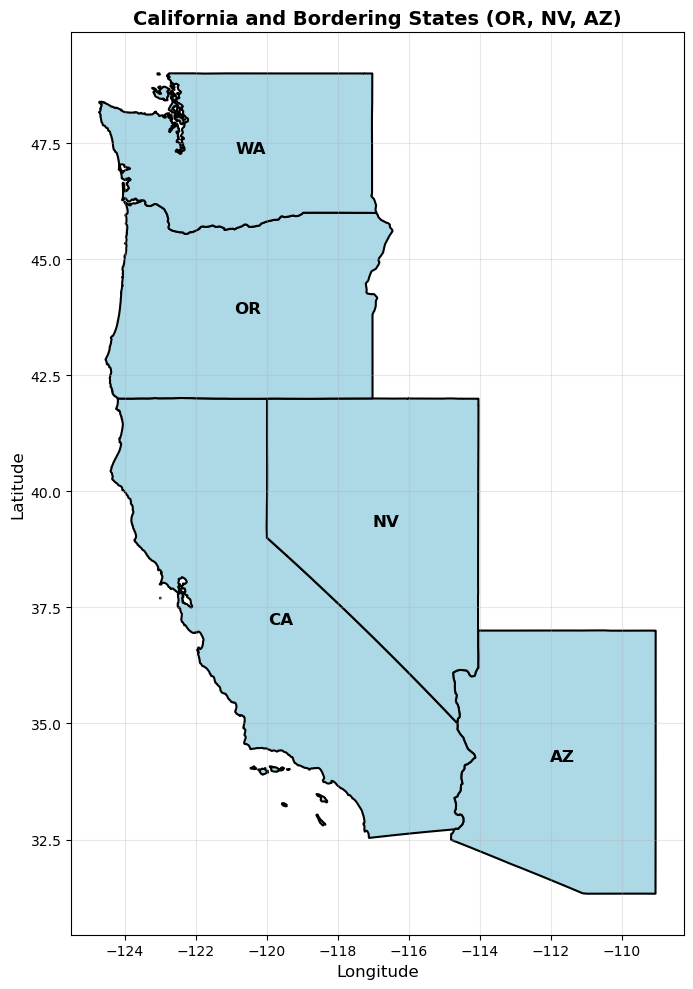

In [22]:
# Visualize the final state boundaries
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot all states
states_gdf.plot(ax=ax, edgecolor='black', facecolor='lightblue', linewidth=1.5)

# Add state labels
for idx, row in states_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row['abbreviation'], 
            fontsize=12, ha='center', va='center', fontweight='bold')

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('California and Bordering States (OR, NV, AZ)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

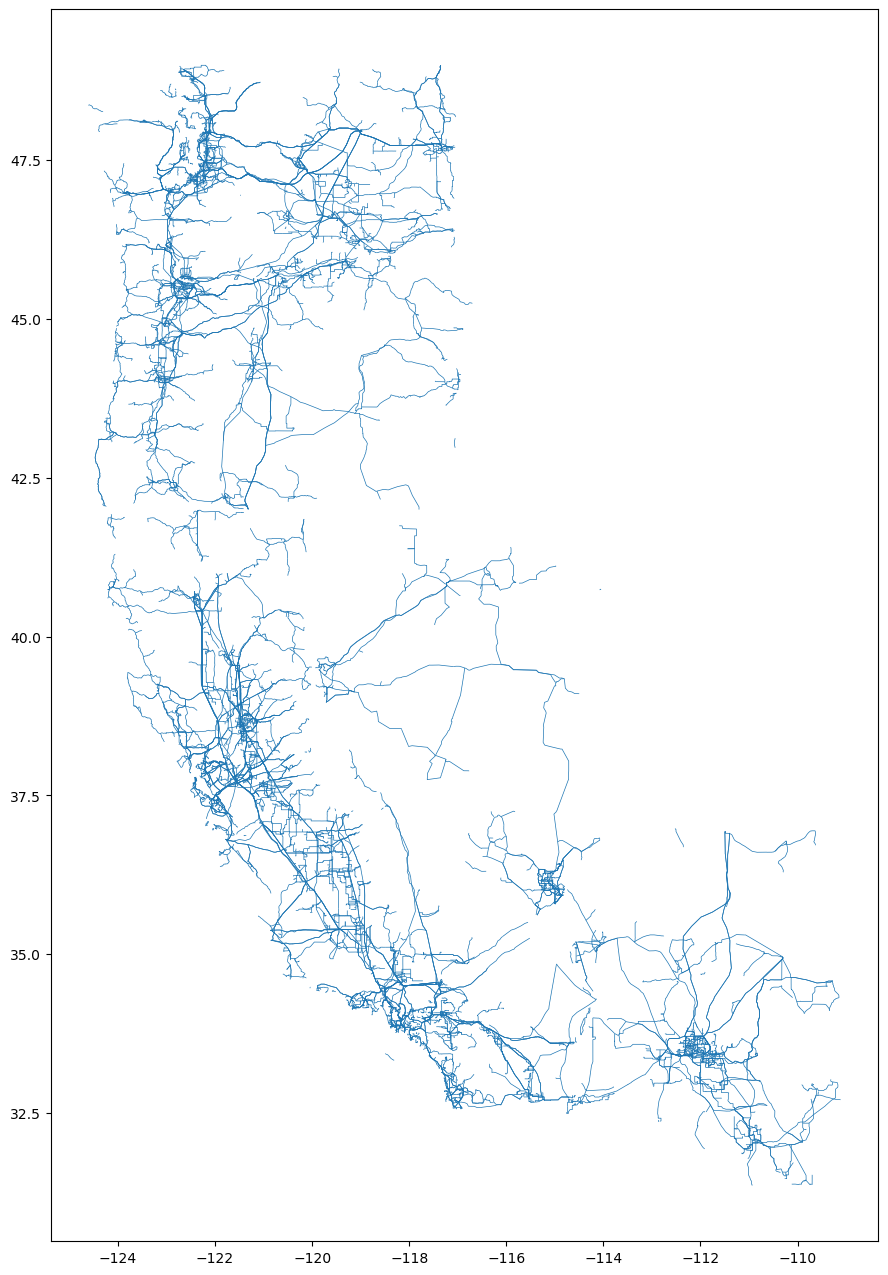

In [26]:
file_path_powergrid = "/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/physical_grid_data/U.S._Electric_Power_Transmission_Lines.geojson"
gdf_powergrid = gpd.read_file(file_path_powergrid)



# Convert timeframes to folium-friendly types
gdf_powergrid['SOURCEDATE'] = pd.to_datetime(gdf_powergrid['SOURCEDATE']).dt.strftime('%Y-%m-%dT%H:%M:%S')
gdf_powergrid['VAL_DATE'] = pd.to_datetime(gdf_powergrid['VAL_DATE']).dt.strftime('%Y-%m-%dT%H:%M:%S')


# Drop columns with 'NOT AVAILABLE' as substation value
# gdf[ (gdf['SUB_1']=='NOT AVAILABLE') | (gdf['SUB_2']=='NOT AVAILABLE')]
condition = ( (gdf_powergrid['SUB_1']=='NOT AVAILABLE') | (gdf_powergrid['SUB_2']=='NOT AVAILABLE') )
gdf_powergrid = gdf_powergrid[~condition]
# gdf

# Drop columns with 'NONE' as substation value
condition = ( (gdf_powergrid['SUB_1']=='NONE') | (gdf_powergrid['SUB_2']=='NONE') )
gdf_powergrid = gdf_powergrid[~condition]
gdf_powergrid



# Clip to ensure only grid elements in the AOI are kept
gdf_powergrid_aoi = gpd.sjoin(gdf_powergrid, states_gdf, how="inner", predicate='within').drop(columns=['index_right'])

powergrid_aoi_map = gdf_powergrid_aoi.plot(figsize=(20, 16),linewidth=0.5)




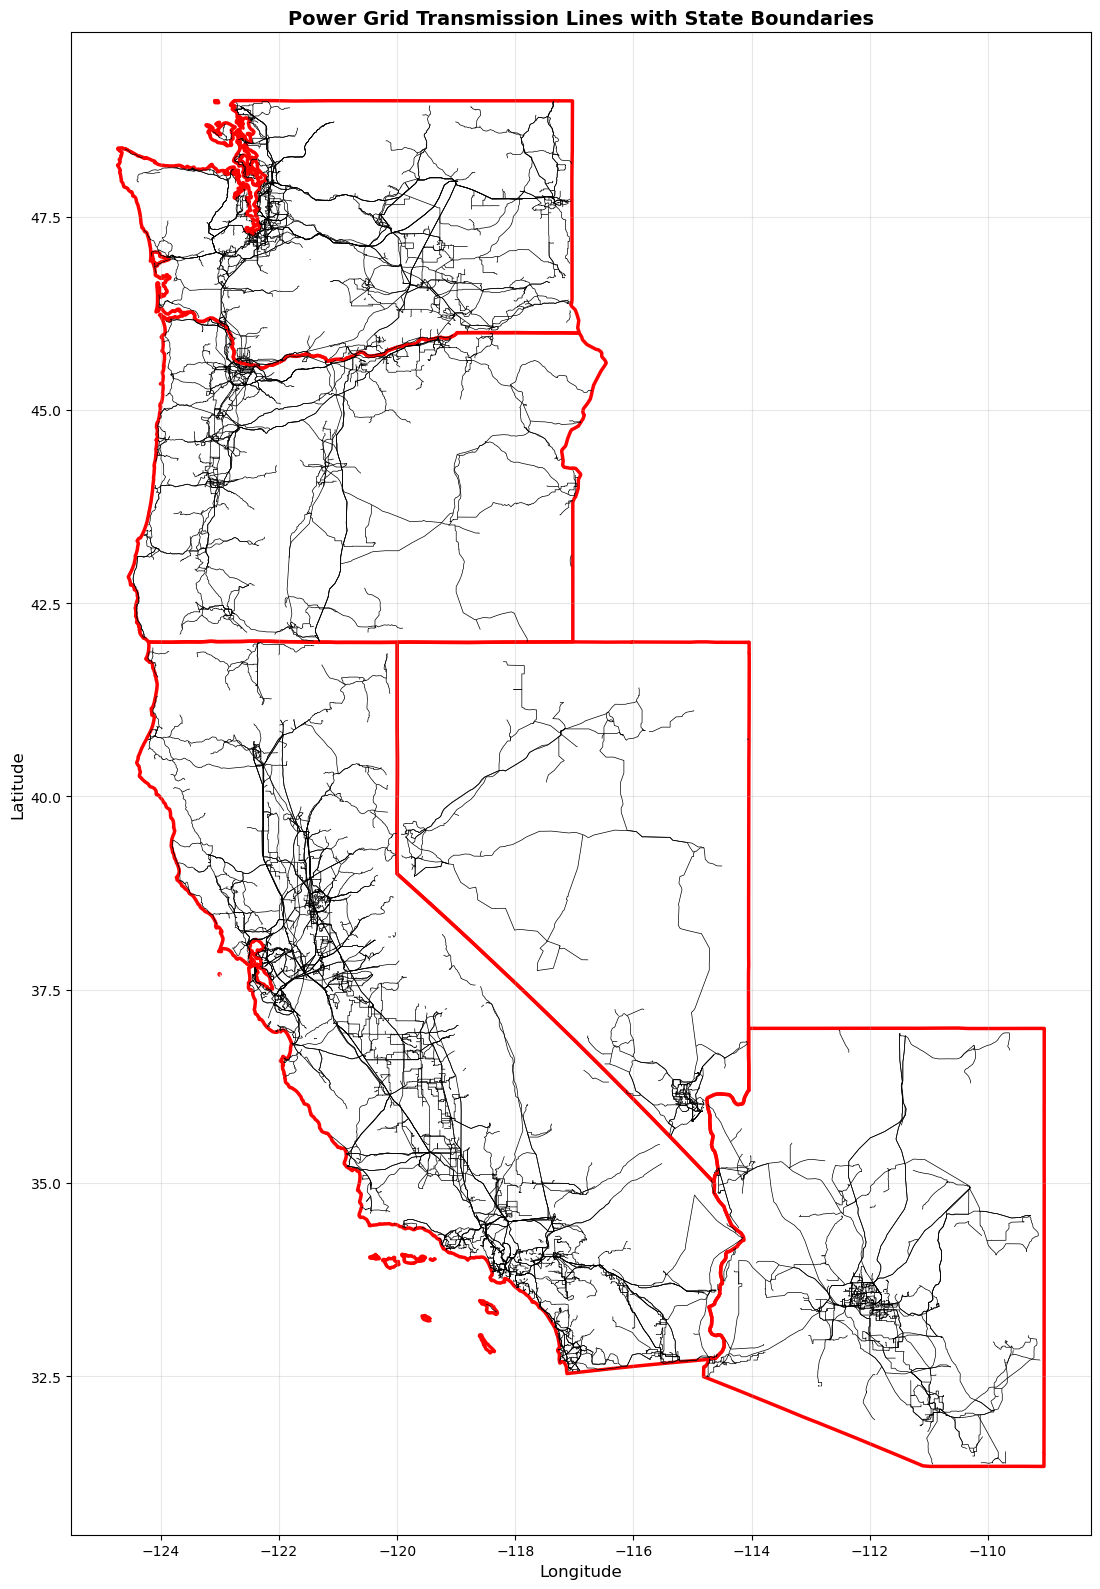

In [28]:
# Clip to ensure only grid elements in the AOI are kept
gdf_powergrid_aoi = gpd.sjoin(gdf_powergrid, states_gdf, how="inner", predicate='within').drop(columns=['index_right'])

# Create figure and axes
fig, ax = plt.subplots(figsize=(20, 16))

# Plot power grid transmission lines
gdf_powergrid_aoi.plot(ax=ax, color='black', linewidth=0.5, label='Transmission Lines')

# Overlay state boundaries on top with different styling
states_gdf.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2.5, label='State Boundaries')

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Power Grid Transmission Lines with State Boundaries', fontsize=14, fontweight='bold')
# ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:


file_wildfire = '/Users/ryanmc/Documents/'